# EV Battery Power Prediction

## Project Overview

In this project, I used real-world vehicle telemetry data to predict electric vehicle battery power demand.

I compared five different regression models to see which could make the most accurate predictions:

- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting
- Neural Network

I evaluated the models using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R².

I also looked at which features were most useful to the models, how large prediction errors were, and how well the best-performing model followed battery power during an example driving sequence.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import sys
print(sys.executable)

C:\Users\bugat\Anaconda\envs\ev-ml\python.exe


In [7]:
import py7zr

## Data Loading
The dataset contains dynamic vehicle measurements as well as static information about the vehicles. I combined these sources using the vehicle ID so that the telemetry data could be used alongside the relevant vehicle specifications.

In [8]:
file = r"C:\Users\bugat\Downloads\VED_Data\VED_171101_week.csv"

df = pd.read_csv(file)

In [9]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (489414, 22)

Columns:
['DayNum', 'VehId', 'Trip', 'Timestamp(ms)', 'Latitude[deg]', 'Longitude[deg]', 'Vehicle Speed[km/h]', 'MAF[g/sec]', 'Engine RPM[RPM]', 'Absolute Load[%]', 'OAT[DegC]', 'Fuel Rate[L/hr]', 'Air Conditioning Power[kW]', 'Air Conditioning Power[Watts]', 'Heater Power[Watts]', 'HV Battery Current[A]', 'HV Battery SOC[%]', 'HV Battery Voltage[V]', 'Short Term Fuel Trim Bank 1[%]', 'Short Term Fuel Trim Bank 2[%]', 'Long Term Fuel Trim Bank 1[%]', 'Long Term Fuel Trim Bank 2[%]']


,DayNum,VehId,Trip,Timestamp(ms),Latitude[deg],Longitude[deg],Vehicle Speed[km/h],MAF[g/sec],Engine RPM[RPM],Absolute Load[%],...,Air Conditioning Power[kW],Air Conditioning Power[Watts],Heater Power[Watts],HV Battery Current[A],HV Battery SOC[%],HV Battery Voltage[V],Short Term Fuel Trim Bank 1[%],Short Term Fuel Trim Bank 2[%],Long Term Fuel Trim Bank 1[%],Long Term Fuel Trim Bank 2[%]
0,1.586651,8,706,0,42.277558,-83.69875,40.0,22.129999,2285.0,49.019608,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.586651,8,706,200,42.277558,-83.69875,40.0,22.129999,2285.0,67.450981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.586651,8,706,1100,42.277558,-83.69875,45.0,22.129999,2285.0,67.450981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.586651,8,706,2100,42.277558,-83.69875,47.0,6.150000,2744.0,67.450981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.586651,8,706,4200,42.277558,-83.69875,48.0,21.440001,1982.0,67.450981,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:

ice_hev = pd.read_excel(
    r"C:\Users\bugat\Downloads\VED_Static_Data_ICE&HEV.xlsx"
)

phev_ev = pd.read_excel(
    r"C:\Users\bugat\Downloads\VED_Static_Data_PHEV&EV.xlsx"
)

In [11]:
print(ice_hev["Vehicle Type"].value_counts())

print(phev_ev["EngineType"].value_counts())

Vehicle Type
ICE    264
HEV     93
Name: count, dtype: int64
EngineType
PHEV    24
EV       3
Name: count, dtype: int64


## Data Preparation
The data was prepared for modelling by selecting the input features and target variable and applying the required preprocessing to the different feature types. The final dataset was split into training and test sets, with the test set kept separate for evaluating the models.

In [7]:
dynamic_ids = set(df["VehId"].unique())

static_ids = set(ice_hev["VehId"]) | set(phev_ev["VehId"])

print("Vehicles in dynamic data:", len(dynamic_ids))
print("Vehicles in static data:", len(static_ids))
print("Matching vehicles:", len(dynamic_ids & static_ids))

Vehicles in dynamic data: 258
Vehicles in static data: 384
Matching vehicles: 258


In [4]:
import glob

files = glob.glob(r"C:\Users\bugat\Downloads\VED_Data\*.csv")

print("Number of files:", len(files))
print("First file:", files[0])

Number of files: 22
First file: C:\Users\bugat\Downloads\VED_Data\VED_171101_week.csv


In [5]:
dynamic_columns = [
    "VehId",
    "Trip",
    "Timestamp(ms)",
    "Vehicle Speed[km/h]",
    "Air Conditioning Power[kW]",
    "Heater Power[Watts]",
    "HV Battery SOC[%]",
    "HV Battery Current[A]",
    "HV Battery Voltage[V]"
]

dynamic_data = pd.concat(
    (
        pd.read_csv(file, usecols=dynamic_columns)
        for file in files
    ),
    ignore_index=True
)

print("Rows:", len(dynamic_data))
print("Columns:", dynamic_data.shape[1])

Rows: 10236957
Columns: 9


In [12]:
ice_hev = ice_hev.rename(columns={"Vehicle Type": "EngineType"})

static_data = pd.concat(
    [ice_hev, phev_ev],
    ignore_index=True
)

print(static_data.shape)
print(static_data["EngineType"].value_counts())

(384, 7)
EngineType
ICE     264
HEV      93
PHEV     24
EV        3
Name: count, dtype: int64


In [14]:
ev_vehicle_ids = set(
    static_data.loc[static_data["EngineType"] == "EV", "VehId"]
)

dynamic_data = dynamic_data[
    dynamic_data["VehId"].isin(ev_vehicle_ids)
].copy()

print("EV dynamic rows:", len(dynamic_data))
print("EV vehicles:", dynamic_data["VehId"].nunique())

EV dynamic rows: 174608
EV vehicles: 3


In [15]:
dynamic_data = dynamic_data.merge(
    static_data,
    on="VehId",
    how="inner"
)

print(dynamic_data.shape)

(174608, 15)


In [16]:
dynamic_data["EngineType"].value_counts()

EngineType
EV    174608
Name: count, dtype: int64

In [17]:
files = glob.glob(
    r"C:\Users\bugat\Downloads\VED_Data\*.csv"
)

print("CSV files:", len(files))

CSV files: 22


In [18]:

electrified_vehicle_ids = set(phev_ev["VehId"])

columns_needed = [
    "DayNum",
    "VehId",
    "Trip",
    "Timestamp(ms)",
    "Vehicle Speed[km/h]",
    "HV Battery Current[A]",
    "HV Battery SOC[%]",
    "HV Battery Voltage[V]",
    "Air Conditioning Power[kW]",
    "Heater Power[Watts]"
]

ev_samples = []

for file in files:
    data = pd.read_csv(file, usecols=columns_needed)

    data = data[data["VehId"].isin(electrified_vehicle_ids)]

    data = data.dropna(
        subset=[
            "HV Battery Current[A]",
            "HV Battery Voltage[V]"
        ]
    )

    if len(data) > 10000:
        data = data.sample(n=10000, random_state=42)

    ev_samples.append(data)

ev_data = pd.concat(ev_samples, ignore_index=True)

print("Dataset shape:", ev_data.shape)

Dataset shape: (220000, 10)


In [19]:
print("Battery current:")
print(ev_data["HV Battery Current[A]"].describe())

print("\nBattery voltage:")
print(ev_data["HV Battery Voltage[V]"].describe())

Battery current:
count    220000.000000
mean        -11.614278
std          39.544206
min        -342.900024
25%         -30.500000
50%          -5.550000
75%           9.150001
max         176.250000
Name: HV Battery Current[A], dtype: float64

Battery voltage:
count    220000.000000
mean        294.342989
std          67.917513
min         164.000000
25%         203.500000
50%         304.000000
75%         354.639984
max         397.875000
Name: HV Battery Voltage[V], dtype: float64


In [20]:
print("\nCurrent percentiles:")
print(ev_data["HV Battery Current[A]"].quantile([0, 0.01, 0.25, 0.5, 0.75, 0.99, 1]))


Current percentiles:
0.00   -342.900024
0.01   -129.400524
0.25    -30.500000
0.50     -5.550000
0.75      9.150001
0.99     91.260394
1.00    176.250000
Name: HV Battery Current[A], dtype: float64


In [21]:
ev_data["Battery Power[kW]"] = (
    ev_data["HV Battery Voltage[V]"]
    * ev_data["HV Battery Current[A]"]
    / 1000
)

print(ev_data["Battery Power[kW]"].describe())

count    220000.000000
mean         -3.794134
std          12.019960
min        -122.555107
25%          -9.207450
50%          -1.564199
75%           2.427939
max          62.378403
Name: Battery Power[kW], dtype: float64


In [22]:
print(
    ev_data["Battery Power[kW]"]
    .quantile([0, 0.01, 0.25, 0.5, 0.75, 0.99, 1])
)

0.00   -122.555107
0.01    -40.622816
0.25     -9.207450
0.50     -1.564199
0.75      2.427939
0.99     25.570368
1.00     62.378403
Name: Battery Power[kW], dtype: float64


In [23]:
phev_ev_static = phev_ev.copy()

phev_ev_static = phev_ev_static.rename(
    columns={"EngineType": "Vehicle Type"}
)

print(phev_ev_static.head())

   VehId Vehicle Type Vehicle Class Engine Configuration & Displacement  \
0      9         PHEV           Car                 4-GAS/ELECTRIC 1.4L   
1     10           EV           Car                            ELECTRIC   
2     11         PHEV           Car                 4-GAS/ELECTRIC 2.0L   
3    371         PHEV           Car                 4-GAS/ELECTRIC 2.0L   
4    379         PHEV           Car                 4-GAS/ELECTRIC 1.4L   

  Transmission Drive Wheels  Generalized_Weight  
0      NO DATA          FWD                4000  
1      NO DATA          FWD                3500  
2          CVT          FWD                4000  
3          CVT          FWD                4000  
4      NO DATA          FWD                4000  


In [24]:
ev_data = ev_data.merge(
    phev_ev_static,
    on="VehId",
    how="left"
)

print(ev_data.shape)

(220000, 17)


In [25]:
ev_data.columns

Index(['DayNum', 'VehId', 'Trip', 'Timestamp(ms)', 'Vehicle Speed[km/h]',
       'Air Conditioning Power[kW]', 'Heater Power[Watts]',
       'HV Battery Current[A]', 'HV Battery SOC[%]', 'HV Battery Voltage[V]',
       'Battery Power[kW]', 'Vehicle Type', 'Vehicle Class',
       'Engine Configuration & Displacement', 'Transmission', 'Drive Wheels',
       'Generalized_Weight'],
      dtype='str')

In [26]:
print(
    ev_data.isna().sum().sort_values(ascending=False)
)

Heater Power[Watts]                    193876
Air Conditioning Power[kW]             172170
DayNum                                      0
VehId                                       0
Trip                                        0
Vehicle Speed[km/h]                         0
Timestamp(ms)                               0
HV Battery Current[A]                       0
HV Battery SOC[%]                           0
HV Battery Voltage[V]                       0
Battery Power[kW]                           0
Vehicle Type                                0
Vehicle Class                               0
Engine Configuration & Displacement         0
Transmission                                0
Drive Wheels                                0
Generalized_Weight                          0
dtype: int64


In [27]:
ev_data["Heater Power[Watts]"] = (
    ev_data["Heater Power[Watts]"].fillna(0)
)

ev_data["Air Conditioning Power[kW]"] = (
    ev_data["Air Conditioning Power[kW]"].fillna(0)
)

print(ev_data.isna().sum().sum())

0


In [28]:

ev_data = ev_data.sort_values(
    ["VehId", "Trip", "Timestamp(ms)"]
).reset_index(drop=True)

ev_data["Time Difference[s]"] = (
    ev_data.groupby(["VehId", "Trip"])["Timestamp(ms)"]
    .diff() / 1000
)

ev_data["Speed Difference[km/h]"] = (
    ev_data.groupby(["VehId", "Trip"])["Vehicle Speed[km/h]"]
    .diff()
)

ev_data["Speed Difference[m/s]"] = (
    ev_data["Speed Difference[km/h]"] / 3.6
)

ev_data["Acceleration[m/s²]"] = (
    ev_data["Speed Difference[m/s]"]
    / ev_data["Time Difference[s]"]
)

print(ev_data["Acceleration[m/s²]"].describe())

count    218410.000000
mean          0.013221
std           0.979974
min         -38.585069
25%          -0.183253
50%           0.000000
75%           0.200551
max          44.444444
Name: Acceleration[m/s²], dtype: float64


In [29]:
print("Acceleration below -5:", (ev_data["Acceleration[m/s²]"] < -5).sum())
print("Acceleration above +5:", (ev_data["Acceleration[m/s²]"] > 5).sum())

print("\nPercentage outside ±5 m/s²:")
print(
    ((ev_data["Acceleration[m/s²]"] < -5) |
     (ev_data["Acceleration[m/s²]"] > 5)).mean() * 100
)

Acceleration below -5: 358
Acceleration above +5: 582

Percentage outside ±5 m/s²:
0.42727272727272725


In [30]:
ev_data = ev_data[
    ev_data["Acceleration[m/s²]"].between(-5, 5)
].copy()

#Removing rows where acceleration couldn't be calculated
ev_data = ev_data.dropna(
    subset=["Acceleration[m/s²]"]
).reset_index(drop=True)

print("Final dataset shape:", ev_data.shape)

Final dataset shape: (217470, 21)


In [31]:
print(ev_data["Battery Power[kW]"].describe())

count    217470.000000
mean         -3.755034
std          11.953054
min        -122.555107
25%          -9.125581
50%          -1.550376
75%           2.432001
max          62.378403
Name: Battery Power[kW], dtype: float64


In [32]:
print(
    ev_data["Battery Power[kW]"].quantile(
        [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
    )
)

0.00   -122.555107
0.01    -40.258211
0.05    -25.520807
0.25     -9.125581
0.50     -1.550376
0.75      2.432001
0.95     13.427894
0.99     25.481885
1.00     62.378403
Name: Battery Power[kW], dtype: float64


In [33]:
print(
    ev_data.loc[
        ev_data["Battery Power[kW]"] < -80,
        [
            "Vehicle Speed[km/h]",
            "Acceleration[m/s²]",
            "HV Battery Current[A]",
            "HV Battery Voltage[V]",
            "Battery Power[kW]"
        ]
    ]
)

        Vehicle Speed[km/h]  Acceleration[m/s²]  HV Battery Current[A]  \
1487              73.489998            0.769097            -265.500000   
5765              56.349998            4.097222            -216.500000   
5766              65.930000            2.661112            -290.500000   
6568              61.469997            2.339947            -250.500000   
7077              59.840000            2.891414            -260.000000   
7118              54.619999            2.209350            -260.500000   
7119              72.669998            3.581349            -256.000000   
7120              86.500000            1.920834            -254.500000   
7121              86.500000            0.000000            -254.500000   
7312              52.079998            2.769231            -249.500000   
7313              78.269997            2.508621            -248.500000   
7314              78.269997            0.000000            -247.500000   
97615             91.875000           

In [34]:
print(
    "Number below -80 kW:",
    (ev_data["Battery Power[kW]"] < -80).sum()
)

Number below -80 kW: 42


In [35]:
features = [
    "Vehicle Speed[km/h]",
    "Acceleration[m/s²]",
    "HV Battery SOC[%]",
    "Air Conditioning Power[kW]",
    "Heater Power[Watts]",
    "Vehicle Class",
    "Engine Configuration & Displacement",
    "Transmission",
    "Drive Wheels",
    "Generalized_Weight"
]

X = ev_data[features].copy()
y = ev_data["Battery Power[kW]"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (217470, 10)
y shape: (217470,)

Features:
['Vehicle Speed[km/h]', 'Acceleration[m/s²]', 'HV Battery SOC[%]', 'Air Conditioning Power[kW]', 'Heater Power[Watts]', 'Vehicle Class', 'Engine Configuration & Displacement', 'Transmission', 'Drive Wheels', 'Generalized_Weight']


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (173976, 10)
Test set: (43494, 10)


## Model Training
I compared five regression models: Linear Regression, Ridge Regression, Random Forest, Gradient Boosting and a Neural Network. This allowed me to compare simpler linear approaches with models that can capture more complex relationships in the data.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "Vehicle Speed[km/h]",
    "Acceleration[m/s²]",
    "HV Battery SOC[%]",
    "Air Conditioning Power[kW]",
    "Heater Power[Watts]",
    "Generalized_Weight"
]

categorical_features = [
    "Vehicle Class",
    "Engine Configuration & Displacement",
    "Transmission",
    "Drive Wheels"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)


In [39]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Vehicle Speed[km/h]','Acceleration[m/s²]','HV Battery SOC[%]',..., 'Transmission','Drive Wheels','Generalized_Weight']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE:  {mae:.3f} kW")
print(f"RMSE: {rmse:.3f} kW")
print(f"R²:   {r2:.3f}")

Linear Regression Results
-------------------------
MAE:  7.472 kW
RMSE: 10.312 kW
R²:   0.249


In [41]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

In [42]:
ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Vehicle Speed[km/h]','Acceleration[m/s²]','HV Battery SOC[%]',..., 'Transmission','Drive Wheels','Generalized_Weight']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [43]:
y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print(f"MAE:  {mae_ridge:.3f} kW")
print(f"RMSE: {rmse_ridge:.3f} kW")
print(f"R²:   {r2_ridge:.3f}")

Ridge Regression Results
------------------------
MAE:  7.472 kW
RMSE: 10.312 kW
R²:   0.249


In [44]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)


In [48]:
random_forest.set_params(
    model__n_jobs=1,
    model__n_estimators=50,
    model__max_depth=15
)

random_forest.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Vehicle Speed[km/h]','Acceleration[m/s²]','HV Battery SOC[%]',..., 'Transmission','Drive Wheels','Generalized_Weight']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [49]:
y_pred_rf = random_forest.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"MAE:  {mae_rf:.3f} kW")
print(f"RMSE: {rmse_rf:.3f} kW")
print(f"R²:   {r2_rf:.3f}")

Random Forest Results
---------------------
MAE:  6.108 kW
RMSE: 8.983 kW
R²:   0.430


In [50]:
from sklearn.ensemble import HistGradientBoostingRegressor

gradient_boosting = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.1,
            max_leaf_nodes=31,
            random_state=42
        ))
    ]
)

In [51]:
gradient_boosting.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Vehicle Speed[km/h]','Acceleration[m/s²]','HV Battery SOC[%]',..., 'Transmission','Drive Wheels','Generalized_Weight']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [52]:
y_pred_gb = gradient_boosting.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE:  {mae_gb:.3f} kW")
print(f"RMSE: {rmse_gb:.3f} kW")
print(f"R²:   {r2_gb:.3f}")

Gradient Boosting Results
-------------------------
MAE:  6.052 kW
RMSE: 8.896 kW
R²:   0.441


In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [54]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline

neural_network = Pipeline(
    steps=[
        ("preprocessor", nn_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=100,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42
        ))
    ]
)

In [55]:
neural_network.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Vehicle Speed[km/h]','Acceleration[m/s²]','HV Battery SOC[%]',..., 'Transmission','Drive Wheels','Generalized_Weight']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [56]:
y_pred_nn = neural_network.predict(X_test)

mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("Neural Network Results")
print("----------------------")
print(f"MAE:  {mae_nn:.3f} kW")
print(f"RMSE: {rmse_nn:.3f} kW")
print(f"R²:   {r2_nn:.3f}")

Neural Network Results
----------------------
MAE:  6.130 kW
RMSE: 8.987 kW
R²:   0.430


In [57]:
hidden_layer_sizes=(64, 32, 16)

In [58]:
neural_network_3layer = Pipeline(
    steps=[
        ("preprocessor", nn_preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32, 16),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=150,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42
        ))
    ]
)

In [59]:
neural_network_3layer.fit(X_train, y_train)

y_pred_nn3 = neural_network_3layer.predict(X_test)

mae_nn3 = mean_absolute_error(y_test, y_pred_nn3)
rmse_nn3 = np.sqrt(mean_squared_error(y_test, y_pred_nn3))
r2_nn3 = r2_score(y_test, y_pred_nn3)

print("Neural Network (64 → 32 → 16)")
print("--------------------------------")
print(f"MAE:  {mae_nn3:.3f} kW")
print(f"RMSE: {rmse_nn3:.3f} kW")
print(f"R²:   {r2_nn3:.3f}")

Neural Network (64 → 32 → 16)
--------------------------------
MAE:  6.140 kW
RMSE: 8.974 kW
R²:   0.431


## Model Evaluation
The models were evaluated using mean absolute error (MAE), root mean squared error (RMSE) and R². Gradient Boosting performed best overall, achieving an MAE of 6.05 kW, an RMSE of 8.90 kW and an R² of 0.441 on the test set.

In [60]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest",
        "Gradient Boosting",
        "Neural Network"
    ],
    "MAE": [
        mae,
        mae_ridge,
        mae_rf,
        mae_gb,
        mae_nn3
    ],
    "RMSE": [
        rmse,
        rmse_ridge,
        rmse_rf,
        rmse_gb,
        rmse_nn3
    ],
    "R²": [
        r2,
        r2_ridge,
        r2_rf,
        r2_gb,
        r2_nn3
    ]
})

results_df = results_df.sort_values("R²", ascending=False)

print(results_df.to_string(index=False))

            Model      MAE      RMSE       R²
Gradient Boosting 6.052248  8.895606 0.441417
   Neural Network 6.139777  8.974430 0.431474
    Random Forest 6.108253  8.983068 0.430379
 Ridge Regression 7.471552 10.312080 0.249365
Linear Regression 7.471603 10.312122 0.249359


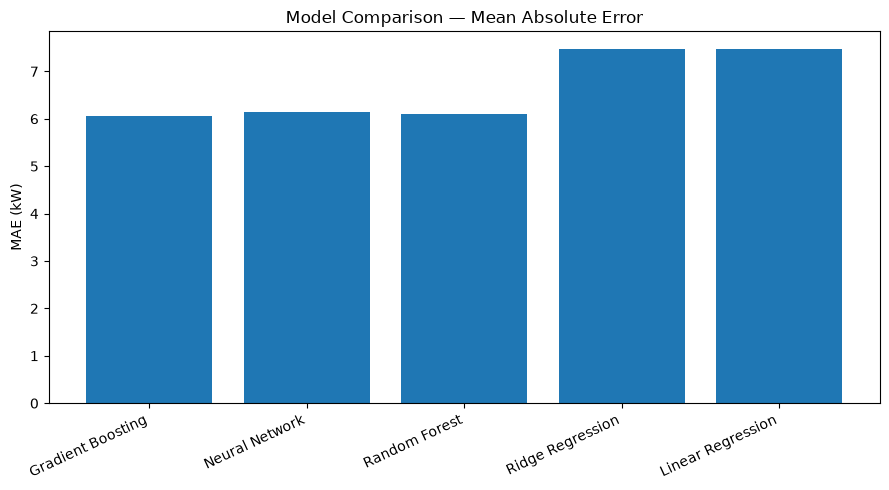

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(results_df["Model"], results_df["MAE"])

plt.ylabel("MAE (kW)")
plt.title("Model Comparison — Mean Absolute Error")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

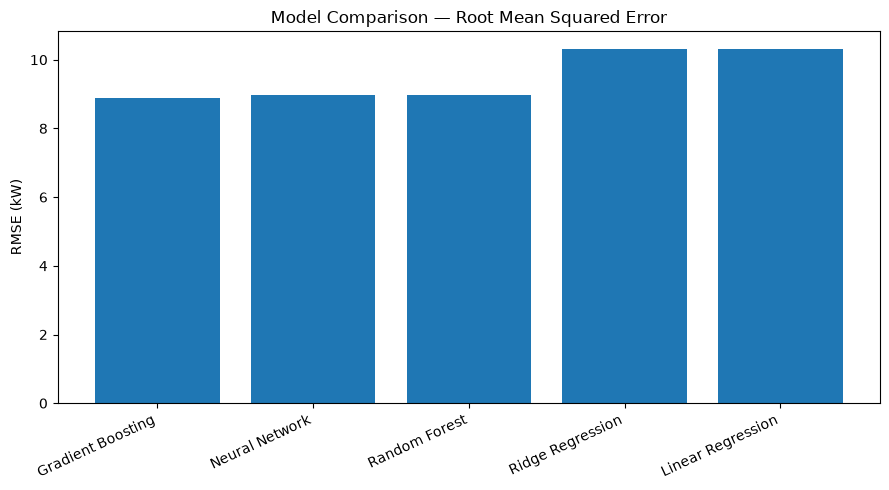

In [62]:
plt.figure(figsize=(9, 5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.ylabel("RMSE (kW)")
plt.title("Model Comparison — Root Mean Squared Error")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

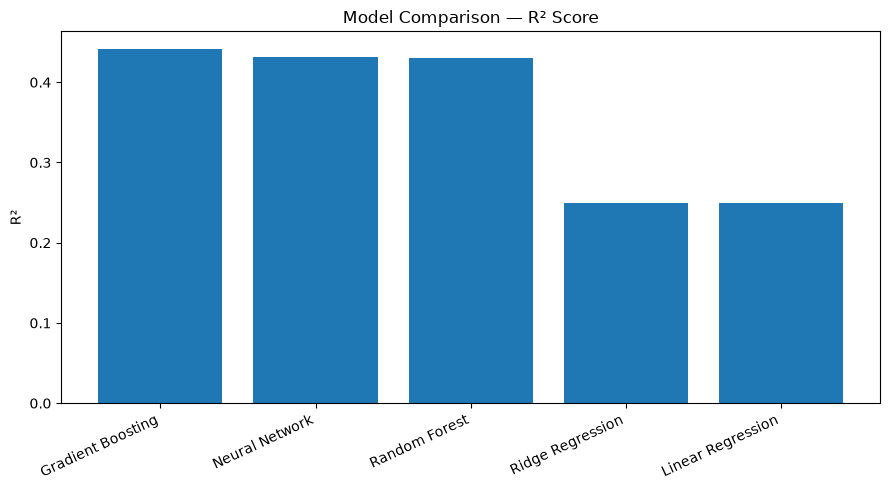

In [63]:
plt.figure(figsize=(9, 5))

plt.bar(results_df["Model"], results_df["R²"])

plt.ylabel("R²")
plt.title("Model Comparison — R² Score")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Residual Analysis
I analysed the residuals from the Gradient Boosting model to get a better idea of how its prediction errors were distributed. About 57.6% of predictions were within 5 kW of the actual value, while 80.1% were within 10 kW and 95.8% were within 20 kW.

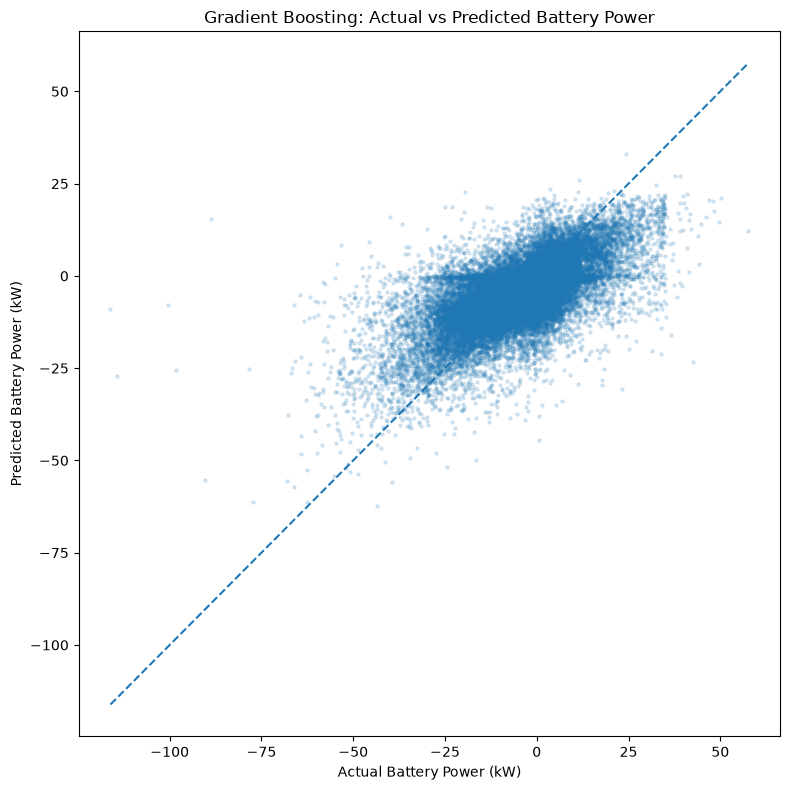

In [64]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred_gb,
    alpha=0.15,
    s=5
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_gb.min())
max_val = max(y_test.max(), y_pred_gb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Battery Power (kW)")
plt.ylabel("Predicted Battery Power (kW)")
plt.title("Gradient Boosting: Actual vs Predicted Battery Power")

plt.tight_layout()
plt.show()

In [65]:
residuals_gb = y_test - y_pred_gb

print("Residual statistics:")
print(residuals_gb.describe())

Residual statistics:
count    43494.000000
mean        -0.001443
std          8.895708
min       -107.021345
25%         -3.687714
50%          0.267107
75%          4.213239
max         65.960949
Name: Battery Power[kW], dtype: float64


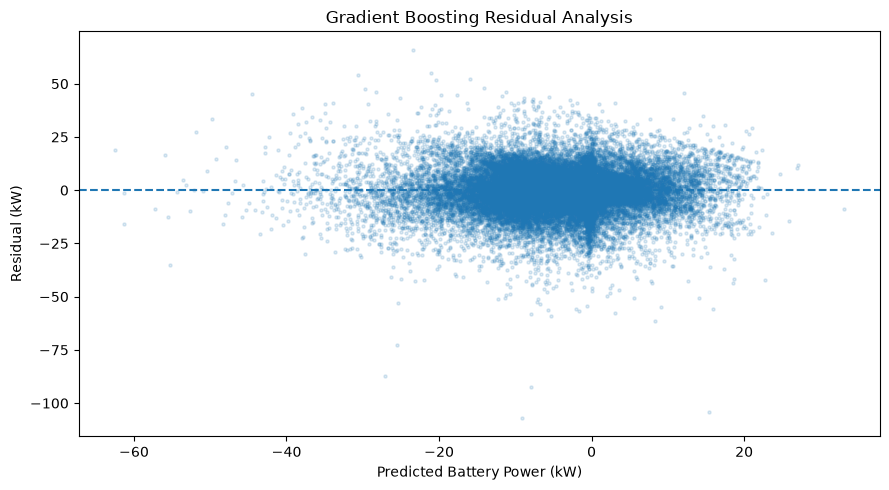

In [66]:
plt.figure(figsize=(9, 5))

plt.scatter(
    y_pred_gb,
    residuals_gb,
    alpha=0.15,
    s=5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Battery Power (kW)")
plt.ylabel("Residual (kW)")
plt.title("Gradient Boosting Residual Analysis")

plt.tight_layout()
plt.show()

In [67]:
print("Within ±5 kW:",
      (residuals_gb.abs() <= 5).mean() * 100)

print("Within ±10 kW:",
      (residuals_gb.abs() <= 10).mean() * 100)

print("Within ±20 kW:",
      (residuals_gb.abs() <= 20).mean() * 100)

Within ±5 kW: 57.63783510369246
Within ±10 kW: 80.11219938382305
Within ±20 kW: 95.84080562836253


## Feature Importance
The feature analysis showed that acceleration, battery state of charge and vehicle speed were the most influential features in the Gradient Boosting model. This suggests that the model relies heavily on information about the vehicle's current motion and battery state when predicting power demand.

In [68]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    gradient_boosting,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=1
)

feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

print(feature_importance.to_string(index=False))

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [ ]:
top_features = feature_importance.head(8).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

## Driving Sequence Analysis
To look at the model's behaviour in a more realistic setting, I selected a continuous driving sequence from the test data and compared the predicted battery power with the actual values over time. This gives a clearer view of how well the model follows changes in battery power during a trip.

In [ ]:
test_analysis = X_test.copy()

test_analysis["Actual_Battery_Power"] = y_test.values
test_analysis["Predicted_Battery_Power"] = y_pred_gb

In [ ]:
test_with_info = ev_data.loc[X_test.index, [
    "VehId",
    "Trip",
    "Timestamp(ms)"
]].copy()

test_with_info["Actual_Battery_Power"] = y_test.values
test_with_info["Predicted_Battery_Power"] = y_pred_gb

In [ ]:
sequence_lengths = (
    test_with_info
    .groupby(["VehId", "Trip"])
    .size()
    .sort_values(ascending=False)
)

print(sequence_lengths.head(10))

In [ ]:
vehicle_id = 560
trip_id = 234

sequence = test_with_info[
    (test_with_info["VehId"] == vehicle_id) &
    (test_with_info["Trip"] == trip_id)
].copy()

sequence = sequence.sort_values("Timestamp(ms)")

print("Sequence length:", len(sequence))
print(sequence.head())

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    sequence["Timestamp(ms)"] / 1000,
    sequence["Actual_Battery_Power"],
    label="Actual"
)

plt.plot(
    sequence["Timestamp(ms)"] / 1000,
    sequence["Predicted_Battery_Power"],
    label="Predicted"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Battery Power (kW)")
plt.title("Gradient Boosting: Battery Power During a Driving Sequence")
plt.legend()

plt.tight_layout()
plt.show()

## Conclusion
Overall, Gradient Boosting gave the best results of the five models tested, although the R² of 0.441 shows that there is still a significant amount of variation that the model does not explain. The results show that acceleration, battery state of charge and vehicle speed are particularly useful features, while the sequence analysis also highlights some of the larger errors made by the model. A useful next step would be to incorporate more time-series information rather than treating each observation independently.